# Analyse van kort durende meetreeksen

Voor het starten van langjarige metingen vanaf zomer 2022.


# Initialisatie

In [2]:
import hydropandas as hpd
import matplotlib.pyplot as plt

import pandas as pd
import os

import numpy as np

import logging
logging.basicConfig(level=logging.INFO)

In [3]:
hpd.__version__

'0.18.1'

In [4]:
import levee_munsflow_kw_helper as lmkw
import plot_helper as ph

In [5]:
DATA_DIR = r'..\data\\'
PLOT_DIR = r'plots\\'

In [6]:
do_run_long_functions = False

# Gegevens

## Neerslag

Langjarige grondwaterreeksen starten in augustus 2022. Daarom neerslag sindsdien downloaden.

In [7]:
start = pd.Timestamp('2007-08-01')
end = pd.Timestamp('2007-12-31')

Via `xy` in ` hpd.PrecipitationObs.from_knmi()` gezocht naar meest nabije station. Dat is Stavenisse. Heeft dagelijkse data.

In [8]:
fn_precip = DATA_DIR + f'precip_stav_{start:%Y%m%d}_{end:%Y%m%d}.json'

if not os.path.exists(fn_precip):
    logging.info(f'Fetching precipitation data from KNMI for nearest station from {start} to {end}')
    precip_stav = hpd.PrecipitationObs.from_knmi(xy=[60_800, 397_350], start=start, end=end, interval='daily', meteo_var='RD')
    precip_stav.to_json(fn_precip)
    logging.info(f'Saved precipitation data to {fn_precip}')
else:
    logging.info(f'Loading precipitation data from {fn_precip}')
    precip_stav = hpd.read_json(fn_precip)

precip_stav.meta['location'] = precip_stav.meta['location'].capitalize()

INFO:root:Fetching precipitation data from KNMI for nearest station from 2007-08-01 00:00:00 to 2007-12-31 00:00:00
INFO:hydropandas.io.knmi:get KNMI data from station nearest to coordinates [60800, 397350] and meteovariable RD
INFO:root:Saved precipitation data to ..\data\\precip_stav_20070801_20071231.json


<Axes: title={'center': 'Daily precipitation at KNMI station Stavenisse\n24-uur som van de neerslag in millimeters van 09.00 voorafgaande dag- 09.00 UTC+1 huidige dag'}, xlabel='YYYYMMDD'>

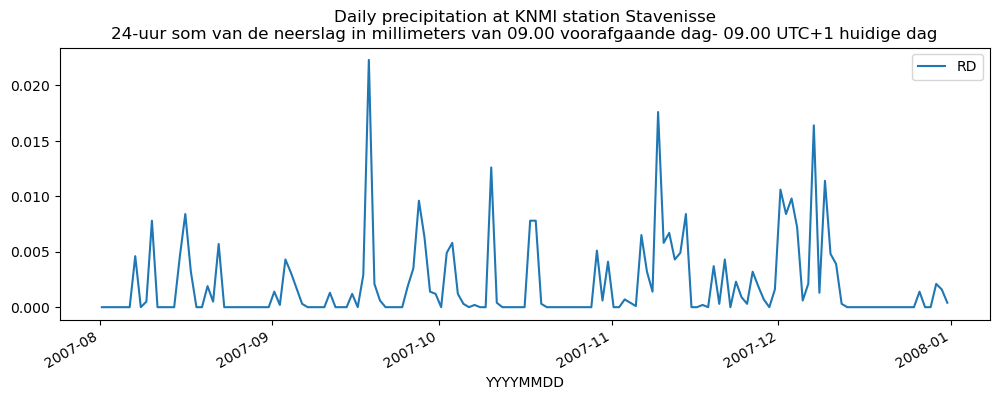

In [9]:
precip_stav.plot(figsize=(12, 4), title=f"Daily precipitation at KNMI station {precip_stav.meta['location']}\n{precip_stav.meta['RD'].split(r'/')[0]}")

## Peilbuizen

Data voorbereid via `N27-2 repo: data\prepare\pbs-oc-collectie.ipynb`, zip gekopieerd van `N27-2 repo: data\obs\json\json.zip`.

In [15]:
obs_gws = lmkw.json_to_hpd(DATA_DIR + 'gws_json.zip')
col_gwl = 'gwl_mnap'

INFO:root:JSON files read: 96
INFO:root:Obs created: 96
INFO:root:ObsCollection created with 96 Obs objects


In [18]:
obs_analyse = obs_gws.copy()
# loop through obs_analyse, in each row drop rows in row.obs where date > 2008-01-01
for idx, row in obs_analyse.iterrows():
    row.obs = row.obs[row.obs.index <= pd.Timestamp('2007-12-31')]
    obs_analyse.at[idx, 'obs'] = row.obs

# loop thourth obs_analyse, check if row.obs is empty after filtering, then drop the row
for idx, row in obs_analyse.iterrows():
    if row.obs.empty:
        obs_analyse.drop(idx, inplace=True)
obs_analyse.reset_index(drop=True, inplace=True)

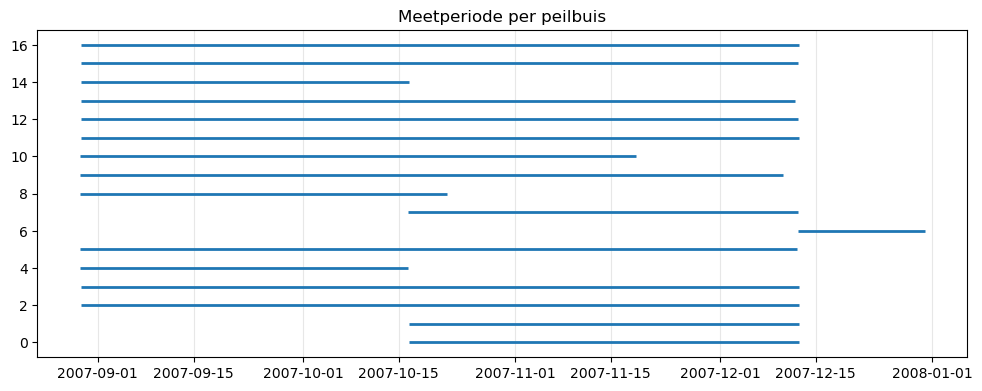

In [19]:
df_first_last = obs_analyse.stats.get_first_last_obs_date().copy()
df_first_last = df_first_last.sort_values(by='date_last_measurement', ascending=True)


fig, ax = plt.subplots(figsize=(12, max(4, 0.25 * len(df_first_last))))
ax.hlines(
    y=df_first_last.index,
    xmin=df_first_last['date_first_measurement'],
    xmax=df_first_last['date_last_measurement'],
    color="tab:blue",
    linewidth=2
)
ax.set_title("Meetperiode per peilbuis")
ax.grid(True, axis="x", alpha=0.3)

## Profielen

Data gekopieerd van `geolookup repo: docs\examples\N27-2_data\table_profielen_Os_dp725-1080.csv`.

In [20]:
df_profiles = pd.read_csv(DATA_DIR + 'table_profielen_Os_dp725-1080.csv')

# voorbeeld van data voor 'bin' and 'kruin', er zijn kolommen met x en y data
df_profiles.loc[:, ['dp'] + df_profiles.columns[df_profiles.columns.str.contains('bin|kruin')].to_list()].head()

,dp,xmv.bin,xkruin.1,xkruin.2,ymv.bin,ykruin.1,ykruin.2
0,725.0,-91.13,-3.404,2.238,1.203,6.39,6.22
1,726.0,-200.88,-2.953,-0.385,1.329,6.43,6.41
2,727.0,-51.22,-2.084,-0.067,1.342,6.51,6.43
3,728.0,-201.00,-2.665,-0.833,1.158,6.45,6.37
4,729.0,-201.00,-2.764,-0.546,1.222,6.46,6.42


# Analyse

## Neerslag

Analyse van de verschillende jaren. Gekozen om cummulatieve neerslag sinds 1 augustus te plotten, tot 31 juli jaar er op. In die periode stijgt namelijk de grondwaterstand in de dijk.

In [21]:
cumulative_start_month = 8
precip_stav_df, month_name = lmkw.calc_cummulative_precip(
    precip_stav,
    cumulative_start_month=cumulative_start_month)

'| 2026-09-08 09:33 | plots\\\\cummulative_precip_2007.png | python_cache\\voorverkenning\\notebooks\\shorter_periods_some_time_ago.ipynb | LAP-008642 | wk20260401 | '

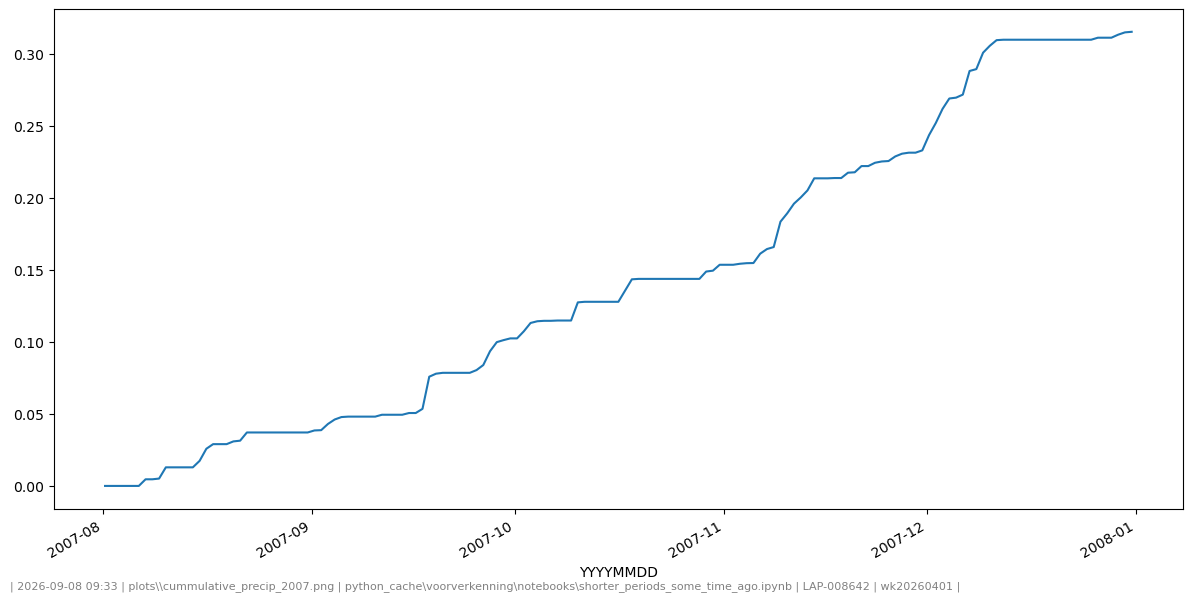

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
precip_stav_df.cumulative.plot(ax=ax)

ph.add_footer_to_fig(fig, PLOT_DIR + f'cummulative_precip_2007.png')

# Peilbuizen

'| 2026-09-08 09:34 | plots\\\\kenmerken_peilbuizen.png | python_cache\\voorverkenning\\notebooks\\shorter_periods_some_time_ago.ipynb | LAP-008642 | wk20260401 | '

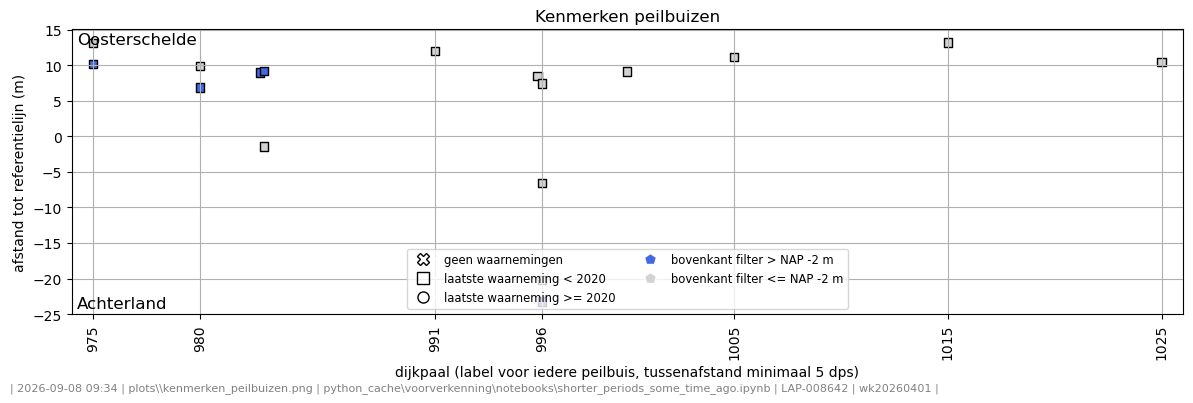

In [25]:
first_last_obs = obs_analyse.stats.get_first_last_obs_date()
obs_analyse['first_obs'] = first_last_obs['date_first_measurement']
# Safely extract year if first_obs is datetime, else set to pd.NA
obs_analyse['first_obs_year'] = obs_analyse['first_obs'].apply(
    lambda x: x.year if pd.notna(x) and hasattr(x, 'year') else pd.NA
)
obs_analyse['last_obs'] = first_last_obs['date_last_measurement']
obs_analyse['last_obs_year'] = obs_analyse['last_obs'].apply(
    lambda x: x.year if pd.notna(x) and hasattr(x, 'year') else pd.NA
)
obs_analyse[['first_obs', 'last_obs']]

from matplotlib.lines import Line2D

# make a plot, x-axis unique values of obs_analyse.dp_plot, y-axis obs_analyse.distance_to_ref, color of marker blue when oc_analyse.screen_top > 0, else blue; marker is square
screen_top_threshold = -2
obs_analyse['color'] = np.where(obs_analyse.screen_top > screen_top_threshold, 'royalblue', 'lightgray')
#obs_gws['zorder'] = np.where(obs_gws.screen_top > 0, 20, 10)  # ensure blue points are plotted on top of gray points
# Add a small vertical offset to distance_to_ref for duplicate (dp, distance_to_ref) combinations
offset = 3 # adjust as needed
grouped = obs_analyse.groupby(['dp', 'distance_to_ref'])
obs_analyse['distance_to_ref_offset'] = obs_analyse['distance_to_ref']  # create a new column for the offset distance
for _, group in grouped:
    if len(group) > 1:
        for i, idx in enumerate(group.index):
            obs_analyse.at[idx, 'distance_to_ref_offset'] += i * offset
            
    else:
        pass
fig, ax = plt.subplots(figsize=(12, 4))
# scatter plot
# use different marker types: X when botn first_obs and last_obs are pd.NA; d when last_obs.year < 2020; o when last_obs.year >= 2020
obs_analyse['marker'] = np.where(obs_analyse['first_obs_year'].isna() & obs_analyse['last_obs_year'].isna(), 'X',
                           np.where(obs_analyse['last_obs_year'] < 2020, 's', 'o'))

marker_map = {
    'X': 'X',  # X
    's': 's',  # diamond
    'o': 'o',  # circle
}

for marker, group in obs_analyse.groupby('marker'):
    ax.scatter(
        group.dp,
        group.distance_to_ref_offset,
        c=group.color,
        marker=marker_map.get(marker, 'o'),
        edgecolor='black',
        label=f"marker: {marker}",
        #zorder=group.zorder,
    )


legend_elements = [
    Line2D([0], [0], marker='X', color='w', label='geen waarnemingen', markerfacecolor='none', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='s', color='w', label='laatste waarneming < 2020', markerfacecolor='none', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='laatste waarneming >= 2020', markerfacecolor='none', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='p', color='w', label=f'bovenkant filter > NAP {screen_top_threshold} m', markerfacecolor='royalblue', markersize=9),
    Line2D([0], [0], marker='p', color='w', label=f'bovenkant filter <= NAP {screen_top_threshold} m', markerfacecolor='lightgray',  markersize=9),
    
]
ax.legend(handles=legend_elements, loc='lower center', fontsize='small', ncols=2)
ax.set_xlim(obs_analyse.dp.min() - 1, obs_analyse.dp.max() + 1)
lim_spacing = 5
# Only place xtick labels when the difference between consecutive dp values is at least 5 units
dp_sorted = np.sort(obs_analyse.dp.unique().round(0))
xticks = []
xticklabels = []
last_dp = None
for dp in dp_sorted:
    if last_dp is None or abs(dp - last_dp) >= lim_spacing:
        xticks.append(dp)
        xticklabels.append(str(int(dp)))
        last_dp = dp
    else:
        # skip label if too close to previous
        pass
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=90)

ax.set_xlabel(f'dijkpaal (label voor iedere peilbuis, tussenafstand minimaal {lim_spacing} dps)')
ax.set_ylabel('afstand tot referentielijn (m)')
ax.text(0.005, 0.99, 'Oosterschelde', transform=ax.transAxes, fontsize=12, va='top')
ax.text(0.005, 0.01, 'Achterland', transform=ax.transAxes, fontsize=12, va='bottom')
ax.set_title('Kenmerken peilbuizen')
ax.grid()
#ax.legend(loc='lower center')

fn = PLOT_DIR + 'kenmerken_peilbuizen.png'
ph.add_footer_to_fig(fig, fn)

In [29]:
do_run_long_functions = True
if do_run_long_functions:
    for raai, oc_raai in obs_analyse.groupby('raai_plot'): # .iloc[:10]
        
        oc_raai = lmkw.add_offset_for_close_points(oc_raai)

        fig, [ax_section, ax_obs] = oc_raai.plots.section_plot(
            cols=[col_gwl],
            section_colname_x='distance_to_ref_plot',
            section_label_x='afstand referentielijn (m)',
            plot_well_layout_markers=True,
        )
        ax_obs.tick_params(axis='x', labelrotation=0)
        ax_obs.set_ylabel('m NAP')
        ax_section.set_ylabel('m NAP')

        # bepaal x-limieten van de tijd-as als timestamps
        x_start, x_end = lmkw.ax_lim_as_dates(ax_obs)
        
        # add new subplot, direct below ax_obs, with same x-limits, for precipitation
        ax_precip = ax_obs.inset_axes([0, -0.4, 1, 0.3],)
        ax_precip.plot(
            precip_stav.loc[x_start:x_end, 'date'], 
            precip_stav.loc[x_start:x_end, 'cumulative'], 
            color='tab:red', 
            linewidth=1.5, 
            label=f'cummulatief sinds 1 {month_name}')
        ax_precip.set_ylabel('neerslag (mm)')
        ax_precip.set_ylim(bottom=0)
        ax_precip.set_xlim([x_start, x_end])
        ax_precip.grid(True)

        lmkw.short_legend_precip(ax_precip)
        
        threshold_additional_plot = pd.Timestamp('2022-08-01')
        if (oc_raai.stats.dates_first_obs.min() < threshold_additional_plot) & (oc_raai.stats.dates_last_obs.max() > threshold_additional_plot):
            ax_zoom = ax_precip.inset_axes([0, -1, 1, 0.9],)
            for index, row in oc_raai.iterrows():
                df_plot = row.obs.loc[threshold_additional_plot:]
                ax_zoom.plot(df_plot.index, df_plot[col_gwl], linewidth=1.5)
            
        fig.suptitle(f"Raai {raai} met neerslag {precip_stav.meta['location']}")
        ph.add_footer_to_fig(fig, PLOT_DIR + f'2007_raai_{raai.replace('.', '_')}.png')
        plt.close()

INFO:hydropandas.extensions.plots:created sectionplot -> 0
INFO:hydropandas.extensions.plots:created sectionplot -> 1
INFO:hydropandas.extensions.plots:created sectionplot -> 2
INFO:hydropandas.extensions.plots:created sectionplot -> 3
INFO:hydropandas.extensions.plots:created sectionplot -> 5
INFO:hydropandas.extensions.plots:created sectionplot -> 6
INFO:hydropandas.extensions.plots:created sectionplot -> 7
INFO:hydropandas.extensions.plots:created sectionplot -> 8
INFO:hydropandas.extensions.plots:created sectionplot -> 10
INFO:hydropandas.extensions.plots:created sectionplot -> 11
INFO:hydropandas.extensions.plots:created sectionplot -> 12
INFO:hydropandas.extensions.plots:created sectionplot -> 13
INFO:hydropandas.extensions.plots:created sectionplot -> 14
INFO:hydropandas.extensions.plots:created sectionplot -> 16
INFO:hydropandas.extensions.plots:created sectionplot -> 15


Text(0.5, 1.0, 'periode 2007-08-28 tot 2007-12-15: Tholen\nalle waarnemingen, bovenkant filter < -3 heeft dunnere lijn en geen label')

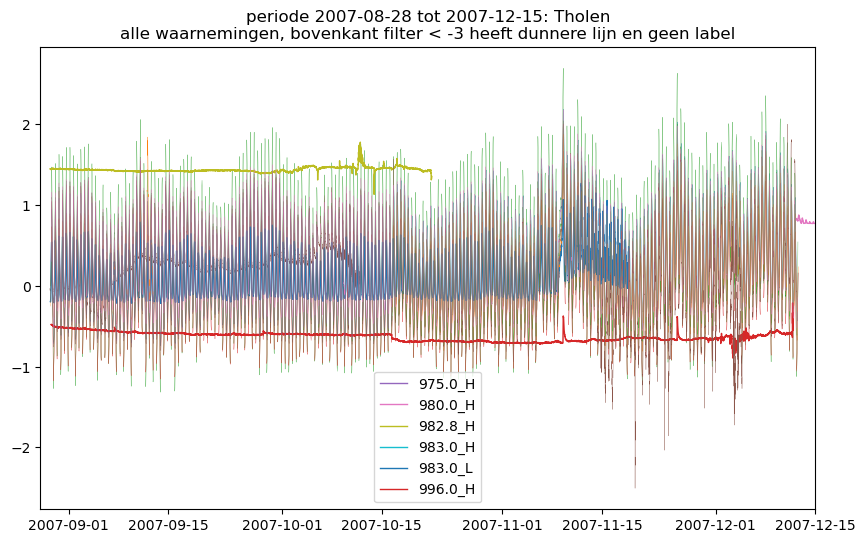

In [47]:
fig, ax = plt.subplots(1, figsize=(10, 6))
for index, row in obs_analyse.iterrows():
    if row.screen_top < -3:
        lw=0.2
        label=''
    else:
        lw=1
        label=f'{row.dp}_{row.filter_letter}'
    ax.plot(row.obs.index, row.obs[col_gwl], '-', linewidth=lw, label=label)
ax.set_xlim([pd.Timestamp('2007-08-28'), pd.Timestamp('2007-12-15')])
ax.legend()
ax.set_title('periode 2007-08-28 tot 2007-12-15: Tholen\n' \
'alle waarnemingen, bovenkant filter < -3 heeft dunnere lijn en geen label')